# Visual Data Exploration



In [1]:
raw_file = "../data/raw_eia923__puerto_rico_generation_fuel.parquet"
annual_file = "../data/pr_gen_fuel_annual.parquet"
monthly_file = "../data/pr_gen_fuel_monthly.parquet"

In [2]:
import pandas as pd
pr_gen_fuel_annual = pd.read_parquet(annual_file)

In [3]:
pr_gen_fuel_annual

,associated_combined_heat_power,census_region,elec_fuel_consumption_mmbtu,electric_fuel_consumption_quantity,energy_source_code,fuel_type_code_agg,fuel_unit,naics_code,nerc_region,nuclear_unit_id,...,plant_state,prime_mover_code,report_year,reporting_frequency_code,sector_id_eia,sector_name_eia,total_fuel_consumption_mmbtu,total_fuel_consumption_quantity,total_net_generation_mwh,data_maturity
0,False,None,1024754.0,0.0,WND,WND,NaN,22,None,None,...,PR,WT,2017,NaN,2,NAICS-22 Non-Cogen,1024754.0,0.0,111229.0,final
1,True,None,85845.0,82921.0,NG,NG,mcf,2122,None,None,...,PR,CA,2017,NaN,7,Industrial NAICS Cogen,85845.0,82921.0,752988.0,final
2,True,None,22632800.0,21916433.0,NG,NG,mcf,2122,None,None,...,PR,CT,2017,NaN,7,Industrial NAICS Cogen,23660771.0,22909642.0,2020310.0,final
3,False,None,274243.0,0.0,SUN,SUN,NaN,22,None,None,...,PR,PV,2017,NaN,2,NAICS-22 Non-Cogen,274243.0,0.0,29767.0,final
4,False,None,24372958.0,1119122.0,BIT,COL,short tons,22,None,None,...,PR,ST,2017,NaN,2,NAICS-22 Non-Cogen,24372958.0,1119122.0,2315554.0,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,False,None,323594.0,55792.0,DFO,DFO,barrels,22,None,None,...,PR,GT,2025,NaN,1,Electric Utility,323594.0,55792.0,25700.0,incremental_ytd
446,False,None,1987852.0,315532.0,RFO,RFO,barrels,22,None,None,...,PR,ST,2025,NaN,1,Electric Utility,1987852.0,315532.0,192938.0,incremental_ytd
447,False,None,833507.0,143708.0,DFO,DFO,barrels,22,None,None,...,PR,GT,2025,NaN,1,Electric Utility,833507.0,143708.0,65800.0,incremental_ytd
448,False,None,662563.0,114235.0,DFO,DFO,barrels,22,None,None,...,PR,GT,2025,NaN,1,Electric Utility,662563.0,114235.0,60462.0,incremental_ytd


In [5]:
# 1. carve off a chunk: what is the primary key?
primary_key_columns = ["plant_id_eia", "report_year"]
pr_gen_fuel_annual.columns

Index(['associated_combined_heat_power', 'census_region',
       'elec_fuel_consumption_mmbtu', 'electric_fuel_consumption_quantity',
       'energy_source_code', 'fuel_type_code_agg', 'fuel_unit', 'naics_code',
       'nerc_region', 'nuclear_unit_id', 'operator_id', 'operator_name',
       'plant_id_eia', 'plant_name_eia', 'plant_state', 'prime_mover_code',
       'report_year', 'reporting_frequency_code', 'sector_id_eia',
       'sector_name_eia', 'total_fuel_consumption_mmbtu',
       'total_fuel_consumption_quantity', 'total_net_generation_mwh',
       'data_maturity'],
      dtype='object')

In [7]:
# what do we expect: every pair of values occurs exactly once
pr_gen_fuel_annual[primary_key_columns].value_counts()

plant_id_eia  report_year
61148         2020           6
              2024           5
61146         2022           5
              2024           5
              2025           5
                            ..
61014         2022           1
              2021           1
              2020           1
              2018           1
              2017           1
Name: count, Length: 283, dtype: int64

In [9]:
# what did we find? too many duplicates :(
pk_sizes = pr_gen_fuel_annual[primary_key_columns].value_counts()
pk_sizes[pk_sizes>1]

plant_id_eia  report_year
61148         2020           6
              2024           5
61146         2022           5
              2024           5
              2025           5
                            ..
61082         2021           2
66127         2023           2
61082         2020           2
              2019           2
66127         2022           2
Name: count, Length: 91, dtype: int64

In [12]:
# explain why? 
pr_gen_fuel_annual.loc[
    (pr_gen_fuel_annual.plant_id_eia == 66127) &
    (pr_gen_fuel_annual.report_year == 2022)
].transpose()

,309,310
associated_combined_heat_power,True,True
census_region,None,None
elec_fuel_consumption_mmbtu,0.0,41133.0
electric_fuel_consumption_quantity,0.0,37771.0
energy_source_code,MWH,NG
fuel_type_code_agg,OTH,NG
fuel_unit,megawatthours,mcf
naics_code,541,541
nerc_region,None,None
nuclear_unit_id,None,None


In [13]:
# explain why: we were missing energy source code
primary_key_columns = primary_key_columns + ["energy_source_code"]
primary_key_columns

['plant_id_eia', 'report_year', 'energy_source_code']

In [14]:
primary_key_columns = primary_key_columns + ["plant_name_eia"]
primary_key_columns

['plant_id_eia', 'report_year', 'energy_source_code', 'plant_name_eia']

In [17]:
pk_sizes = pr_gen_fuel_annual[primary_key_columns].value_counts()
pk_sizes.loc[pk_sizes > 1]

plant_id_eia  report_year  energy_source_code  plant_name_eia          
61146         2024         DFO                 Aguirre Plant               4
              2017         DFO                 Aguirre Plant               4
              2023         DFO                 Aguirre Plant               4
              2025         DFO                 Aguirre Plant               4
              2022         DFO                 Aguirre Plant               4
              2021         DFO                 Aguirre Plant               4
              2020         DFO                 Aguirre Plant               4
              2019         DFO                 Aguirre Plant               4
              2018         DFO                 Aguirre Plant               4
61148         2020         NG                  Central San Juan Plant      3
61034         2018         NG                  EcoElectrica                2
62410         2020         DFO                 Cervecera de Puerto Rico    2
6114

# Challenge: Look at one of the duplicate entries and propose another column to add to the primary key


In [18]:
# explain why? 
pr_gen_fuel_annual.loc[
    (pr_gen_fuel_annual.plant_id_eia == 61148) &
    (pr_gen_fuel_annual.report_year == 2022) & 
    (pr_gen_fuel_annual.energy_source_code == "DFO")
].transpose()

,279,281
associated_combined_heat_power,True,True
census_region,None,None
elec_fuel_consumption_mmbtu,0.0,3203398.0
electric_fuel_consumption_quantity,0.0,557559.0
energy_source_code,DFO,DFO
fuel_type_code_agg,DFO,DFO
fuel_unit,barrels,barrels
naics_code,22,22
nerc_region,None,None
nuclear_unit_id,None,None


In [19]:
primary_key_columns = primary_key_columns + ["prime_mover_code"]
primary_key_columns

['plant_id_eia',
 'report_year',
 'energy_source_code',
 'plant_name_eia',
 'prime_mover_code']

In [20]:
pr_gen_fuel_annual[primary_key_columns].value_counts()

plant_id_eia  report_year  energy_source_code  plant_name_eia              prime_mover_code
62410         2020         DFO                 Cervecera de Puerto Rico    IC                  2
61014         2017         WND                 Pattern Santa Isabel LLC    WT                  1
61148         2025         NG                  Central San Juan Plant      CT                  1
61150         2022         DFO                 Cambalache Plant            GT                  1
              2021         DFO                 Cambalache Plant            GT                  1
                                                                                              ..
61132         2018         WND                 Punta Lima Wind Farm        WT                  1
              2017         WND                 Punta Lima Wind Farm        WT                  1
61114         2023         SUN                 Canovanas Filtration Plant  PV                  1
              2022         SUN     

In [ ]:
# what we expect: occur no more than once
# what did we find? only one duplicate
# explain why? probably data entry error

# Split columns by data type

* Numeric data (whole numbers: integers or ints) (decimal fractions: floats)
* Categorical data
* Free text

In [21]:
pr_gen_fuel_annual.dtypes

associated_combined_heat_power               boolean
census_region                                 object
elec_fuel_consumption_mmbtu                  float64
electric_fuel_consumption_quantity           float64
energy_source_code                          category
fuel_type_code_agg                          category
fuel_unit                                   category
naics_code                                     Int64
nerc_region                                   object
nuclear_unit_id                               object
operator_id                                    Int64
operator_name                         string[python]
plant_id_eia                                   Int64
plant_name_eia                        string[python]
plant_state                                 category
prime_mover_code                            category
report_year                                    Int64
reporting_frequency_code                    category
sector_id_eia                                 

In [22]:
# carve off a chunk: category data
pr_gen_fuel_annual.dtypes["energy_source_code"]

CategoricalDtype(categories=['BIT', 'DFO', 'MWH', 'NG', 'RFO', 'SUN', 'WAT', 'WND'], ordered=False, categories_dtype=object)

# Challenge: use the available values and the EIA-923 documentation to figure out what reporting_frequency_code probably means

In [23]:
pr_gen_fuel_annual.dtypes["reporting_frequency_code"]

CategoricalDtype(categories=['A', 'AM', 'M'], ordered=False, categories_dtype=object)

In [27]:
# carve off a chunk: what columns contain category data?
category_columns = list(pr_gen_fuel_annual.dtypes[
    pr_gen_fuel_annual.dtypes == "category"
].index)

In [29]:
pr_gen_fuel_annual[category_columns].describe()

,energy_source_code,fuel_type_code_agg,fuel_unit,plant_state,prime_mover_code,reporting_frequency_code,data_maturity
count,450,450,319,450,450,349,450
unique,8,8,4,1,9,3,2
top,DFO,DFO,barrels,PR,PV,M,final
freq,188,188,237,450,99,181,417


In [ ]:
# what do we expect?
# count: no nulls (=number of rows)
# unique: match category dtype count, ~match documentation
# top&freq: plausible

In [30]:
pr_gen_fuel_annual.energy_source_code.value_counts()

energy_source_code
DFO    188
SUN     99
NG      49
RFO     49
MWH     24
WND     17
WAT     15
BIT      9
Name: count, dtype: int64

# challenge: use the .describe() output and EIA-923 docs to figure out if fuel_unit makes sense

In [31]:
pr_gen_fuel_annual.fuel_unit.describe()

count         319
unique          4
top       barrels
freq          237
Name: fuel_unit, dtype: object

In [ ]:
# what we expect:
# count: no nulls (found some nulls :(
# uniuqe: 

In [32]:
pr_gen_fuel_annual.fuel_unit.value_counts()

fuel_unit
barrels          237
mcf               49
megawatthours     24
short tons         9
Name: count, dtype: int64

In [ ]:
# what we found: rogue fuel unit
# explain why: look at how megawatthours is used in the data

In [34]:
pr_gen_fuel_annual.loc[
    (pr_gen_fuel_annual.fuel_unit =="megawatthours"),
    category_columns
]
# battery prime mover has megawatthours

,energy_source_code,fuel_type_code_agg,fuel_unit,plant_state,prime_mover_code,reporting_frequency_code,data_maturity
5,MWH,OTH,megawatthours,PR,BA,NaN,final
7,MWH,OTH,megawatthours,PR,BA,NaN,final
40,MWH,OTH,megawatthours,PR,BA,M,final
42,MWH,OTH,megawatthours,PR,BA,M,final
83,MWH,OTH,megawatthours,PR,BA,M,final
86,MWH,OTH,megawatthours,PR,BA,M,final
93,MWH,OTH,megawatthours,PR,BA,A,final
138,MWH,OTH,megawatthours,PR,BA,M,final
141,MWH,OTH,megawatthours,PR,BA,M,final
148,MWH,OTH,megawatthours,PR,BA,A,final


In [35]:
category_columns

['energy_source_code',
 'fuel_type_code_agg',
 'fuel_unit',
 'plant_state',
 'prime_mover_code',
 'reporting_frequency_code',
 'data_maturity']

# Take a quick break

# Monthly data

In [36]:
pr_gen_fuel_monthly = pd.read_parquet(monthly_file)
pr_gen_fuel_monthly

,plant_id_eia,plant_name_eia,prime_mover_code,energy_source_code,fuel_unit,fuel_consumed_for_electricity_mmbtu,fuel_consumed_for_electricity_units,fuel_consumed_mmbtu,fuel_consumed_units,net_generation_mwh,date
0,61014,Pattern Santa Isabel LLC,WT,WND,NaN,101260.0,0.0,101260.0,0.0,10991.0,2017-04-01
1,61034,EcoElectrica,CA,NG,mcf,0.0,0.0,0.0,0.0,86494.0,2017-04-01
2,61034,EcoElectrica,CT,NG,mcf,1976130.0,1976130.0,1976130.0,1976130.0,189669.0,2017-04-01
3,61036,AES ILUMINA,PV,SUN,NaN,31886.0,0.0,31886.0,0.0,3461.0,2017-04-01
4,61082,AES Puerto Rico,ST,BIT,short tons,3258736.0,150103.0,3258736.0,150103.0,310975.0,2017-04-01
...,...,...,...,...,...,...,...,...,...,...,...
5362,61149,Palo Seco Plant,GT,DFO,barrels,332108.0,57260.0,332108.0,57260.0,25652.0,2024-09-01
5363,61149,Palo Seco Plant,ST,RFO,barrels,1041201.0,165270.0,1041201.0,165270.0,98601.0,2024-09-01
5364,61150,Cambalache Plant,GT,DFO,barrels,633760.0,109269.0,633760.0,109269.0,51293.0,2024-09-01
5365,61151,Mayaguez Plant,GT,DFO,barrels,526019.0,90693.0,526019.0,90693.0,48201.0,2024-09-01


In [79]:
primary_key_columns = ["plant_id_eia", "plant_name_eia", "prime_mover_code", "energy_source_code", "date"]
pk_sizes = pr_gen_fuel_monthly[primary_key_columns].value_counts()
pk_sizes.loc[pk_sizes>1]

Series([], Name: count, dtype: int64)

In [72]:
pr_gen_fuel_monthly.loc[
    (pr_gen_fuel_monthly.plant_id_eia == 61147) &
    (pr_gen_fuel_monthly.plant_name_eia == "Costa Sur Plant") &
    (pr_gen_fuel_monthly.prime_mover_code == "ST") &
    (pr_gen_fuel_monthly.date == "2017-11-01")
]

,plant_id_eia,plant_name_eia,prime_mover_code,energy_source_code,fuel_unit,fuel_consumed_for_electricity_mmbtu,fuel_consumed_for_electricity_units,fuel_consumed_mmbtu,fuel_consumed_units,net_generation_mwh,date
4068,61147,Costa Sur Plant,ST,NG,mcf,1276186.0,1215415.0,1347227.0,1283073.0,96561.733,2017-11-01
4069,61147,Costa Sur Plant,ST,RFO,barrels,78720.0,12456.0,83102.0,13149.0,5956.267,2017-11-01


<Axes: xlabel='date', ylabel='net_generation_mwh'>

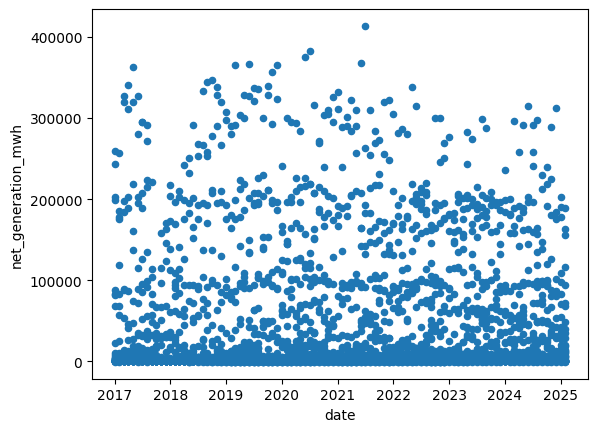

In [111]:
pr_gen_fuel_monthly.plot(x="date",y="net_generation_mwh",kind="scatter")

<Axes: xlabel='date'>

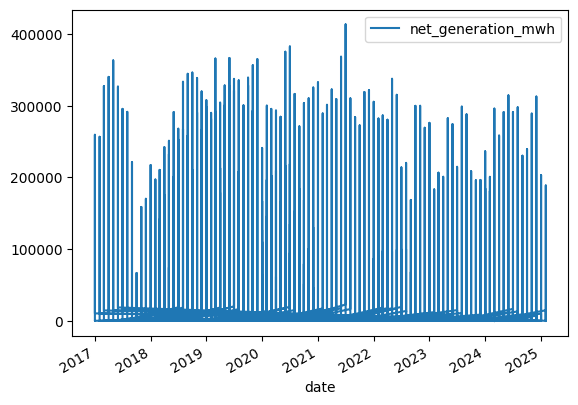

In [106]:
(
    pr_gen_fuel_monthly.set_index(primary_key_columns)
    [["net_generation_mwh"]]
    .reset_index("date")
    # .unstack(["plant_id_eia", "plant_name_eia", "prime_mover_code", "energy_source_code"])
    # .dtypes
    .plot(kind="line",x="date")
)

In [69]:
pr_gen_fuel_monthly.dtypes

plant_id_eia                                    Int64
plant_name_eia                         string[python]
prime_mover_code                             category
energy_source_code                           category
fuel_unit                                    category
fuel_consumed_for_electricity_mmbtu           float64
fuel_consumed_for_electricity_units           float64
fuel_consumed_mmbtu                           float64
fuel_consumed_units                           float64
net_generation_mwh                            float64
date                                   datetime64[ns]
dtype: object

In [37]:
pr_gen_fuel_monthly.date

0      2017-04-01
1      2017-04-01
2      2017-04-01
3      2017-04-01
4      2017-04-01
          ...    
5362   2024-09-01
5363   2024-09-01
5364   2024-09-01
5365   2024-09-01
5366   2024-09-01
Name: date, Length: 5058, dtype: datetime64[ns]

In [39]:
pr_gen_fuel_monthly.date.value_counts().sort_index()

date
2017-01-01    35
2017-02-01    35
2017-03-01    35
2017-04-01    35
2017-05-01    35
              ..
2024-10-01    33
2024-11-01    33
2024-12-01    33
2025-01-01    33
2025-02-01    33
Name: count, Length: 98, dtype: int64

In [40]:
# decide what we want to see
# get pandas to show it to us
# if what we want to see is too hard to see, refine plot
# make a note of anything weird or surprising

In [42]:
# want to plot monthly variables
# a different line for each variable
# one value for each month -- sum across all plants
pr_gen_fuel_monthly.columns

Index(['plant_id_eia', 'plant_name_eia', 'prime_mover_code',
       'energy_source_code', 'fuel_unit',
       'fuel_consumed_for_electricity_mmbtu',
       'fuel_consumed_for_electricity_units', 'fuel_consumed_mmbtu',
       'fuel_consumed_units', 'net_generation_mwh', 'date'],
      dtype='object')

In [43]:
monthly_index_columns = [
    "date",
    "plant_id_eia",
    "plant_name_eia",
    "prime_mover_code",
    "energy_source_code",
    "fuel_unit",
]

In [46]:
pr_gen_fuel_monthly.dtypes

plant_id_eia                                    Int64
plant_name_eia                         string[python]
prime_mover_code                             category
energy_source_code                           category
fuel_unit                                    category
fuel_consumed_for_electricity_mmbtu           float64
fuel_consumed_for_electricity_units           float64
fuel_consumed_mmbtu                           float64
fuel_consumed_units                           float64
net_generation_mwh                            float64
date                                   datetime64[ns]
dtype: object

In [114]:
pr_gen_fuel_monthly.energy_source_code.value_counts().sort_index()

energy_source_code
BIT      98
DFO    2104
MWH     268
NG      538
RFO     548
SUN    1148
WAT     170
WND     184
Name: count, dtype: int64

In [47]:
monthly_index_columns

['date',
 'plant_id_eia',
 'plant_name_eia',
 'prime_mover_code',
 'energy_source_code',
 'fuel_unit']

<Axes: xlabel='date'>

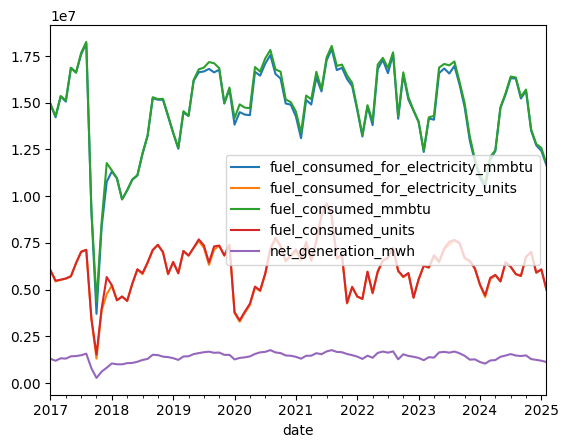

In [50]:
pr_gen_fuel_monthly.set_index(monthly_index_columns).groupby("date").sum().plot()

In [ ]:
# can we see the things we wanted? yes
# write down the surprises
# zero spike in 2017 - probably Maria
# annual cyclic pattern


In [ ]:
# what do we want to see?
# a different line for each energy source: DFO, SUN, etc
# just fuel consumed mmbtus
# just one value for each month, sum across plants

<Axes: xlabel='date'>

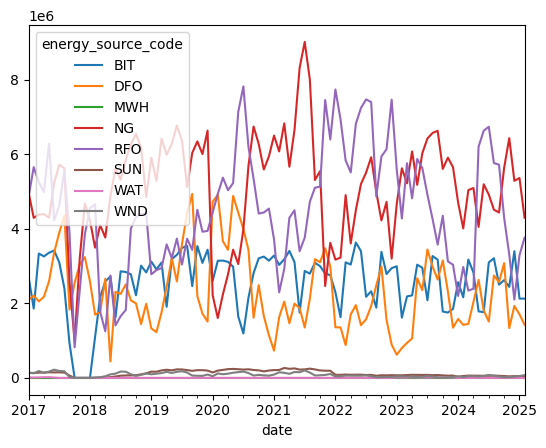

In [57]:
(
    pr_gen_fuel_monthly
    .groupby(["energy_source_code","date"], observed=True)
    .fuel_consumed_mmbtu
    .sum()
    .unstack("energy_source_code")
).plot()

In [ ]:
# one line per energy source?
# what do you notice?

In [58]:
# what's up with renewables starting in 2022?
renewables = ["SUN", "WAT", "WND"]

<Axes: xlabel='date'>

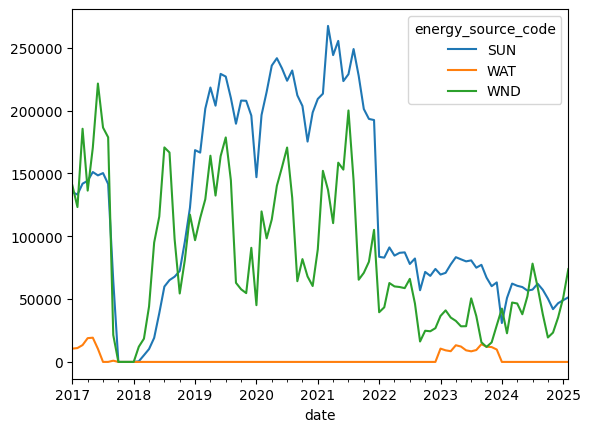

In [61]:
(
    pr_gen_fuel_monthly.loc[
        pr_gen_fuel_monthly.energy_source_code.isin(renewables)
    ]
    
    .groupby(["energy_source_code","date"], observed=True)
    .fuel_consumed_mmbtu
    .sum()
    .unstack("energy_source_code")
).plot()

# Challenge: Adapt this plot to show net_generation_mwh instead

<Axes: xlabel='date'>

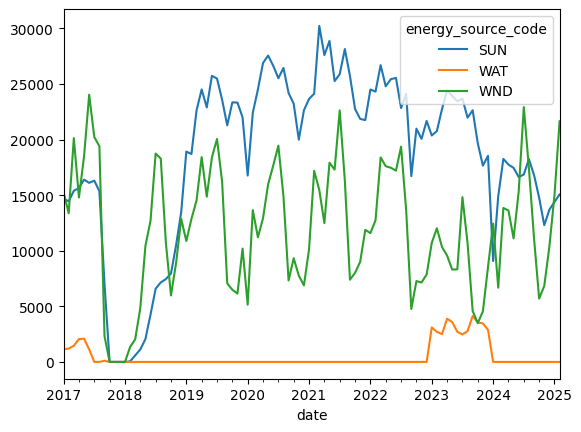

In [62]:
(
    pr_gen_fuel_monthly.loc[
        pr_gen_fuel_monthly.energy_source_code.isin(renewables)
    ]
    .groupby(["energy_source_code","date"], observed=True)
    .net_generation_mwh
    .sum()
    .unstack("energy_source_code")
).plot()

In [63]:
# what do we want to see?
# relationship between netgen and fuel consumed
# scatter plot: one point for each row
# net generation on the x axis
# fuel consumed on the y axis

renewables_monthly = pr_gen_fuel_monthly.loc[
        pr_gen_fuel_monthly.energy_source_code.isin(renewables)
    ]
renewables_monthly

,plant_id_eia,plant_name_eia,prime_mover_code,energy_source_code,fuel_unit,fuel_consumed_for_electricity_mmbtu,fuel_consumed_for_electricity_units,fuel_consumed_mmbtu,fuel_consumed_units,net_generation_mwh,date
0,61014,Pattern Santa Isabel LLC,WT,WND,NaN,101260.0,0.0,101260.0,0.0,10991.0,2017-04-01
3,61036,AES ILUMINA,PV,SUN,NaN,31886.0,0.0,31886.0,0.0,3461.0,2017-04-01
6,61083,Oriana Energy,PV,SUN,NaN,75316.0,0.0,75316.0,0.0,8175.0,2017-04-01
9,61110,San Fermin Solar Farm,PV,SUN,NaN,31462.0,0.0,31462.0,0.0,3415.0,2017-04-01
10,61132,Punta Lima Wind Farm,WT,WND,NaN,35019.0,0.0,35019.0,0.0,3801.0,2017-04-01
...,...,...,...,...,...,...,...,...,...,...,...
5343,61083,Oriana Energy Hybrid,PV,SUN,NaN,25252.0,0.0,25252.0,0.0,7401.0,2024-09-01
5346,61110,San Fermin Solar Farm Hybrid,PV,SUN,NaN,3033.0,0.0,3033.0,0.0,889.0,2024-09-01
5347,61132,Punta Lima Wind Farm,WT,WND,NaN,7571.0,0.0,7571.0,0.0,2219.0,2024-09-01
5348,61133,"Humacao Solar Project, LLC",PV,SUN,NaN,19592.0,0.0,19592.0,0.0,5742.0,2024-09-01


# Challenge: is there a column that will color-separate the lines?

<Axes: xlabel='net_generation_mwh', ylabel='fuel_consumed_mmbtu'>

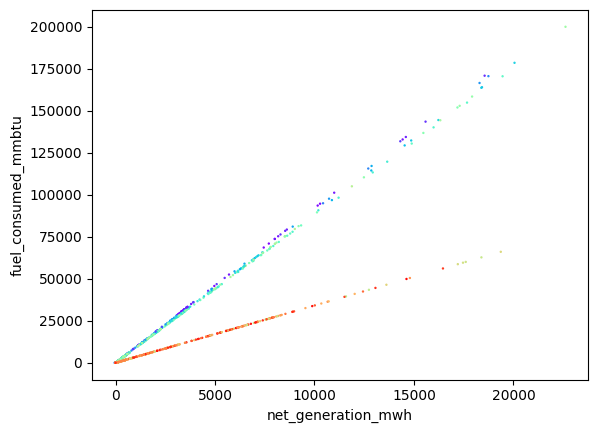

In [68]:
renewables_monthly.plot.scatter(
    x="net_generation_mwh",
    y="fuel_consumed_mmbtu",
    s=0.5,
    c="date",
    colormap="rainbow"
)